In [1]:
#Data Handling
import pandas as pd
import numpy as np

In [2]:
#Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression

In [4]:
#Preprocessing & Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer

In [27]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [6]:
#Utilities
import warnings
warnings.filterwarnings("ignore")
# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

In [83]:
#Apply plotting theme
plt.style.use("ggplot")
#Set seaborn color palette
sns.set_palette("husl")

In [15]:
COL_NAMES = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised","root_shell",
    "su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty_level"
]

In [16]:
train_path = "./data/KCDTrain.txt"
test_path = "./data/KCDTest.txt"
df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
print("Training Data Shape:", df_train.shape)
print("Test Data Shape:", df_test.shape)
#here loading the test and train

Training Data Shape: (125973, 43)
Test Data Shape: (22544, 43)


In [104]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(336715, 54)
Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate',
       'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate', 'is_outlier',
       'log_duration', 'log_src_bytes', 'log_dst_bytes', 'total_bytes',
       'src_bytes_ratio', 'error_flag_indicator', 'service_freq',
       'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp',
       'flag_OTH', 'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH', 'atta

In [117]:
# Attack Category Mapping
attack_mapping = {
    'normal': 'normal',
    # DoS Attacks
    'back': 'dos',
    'land': 'dos',
    'neptune': 'dos',
    'pod': 'dos',
    'smurf': 'dos',
    'teardrop': 'dos',
    # Probe Attacks
    'ipsweep': 'probe',
    'nmap': 'probe',
    'portsweep': 'probe',
    'satan': 'probe',
    # R2L Attacks
    'ftp_write': 'r2l',
    'guess_passwd': 'r2l',
    'imap': 'r2l',
    'multihop': 'r2l',
}

In [18]:
df_train["attack_class"] = df_train["label"].map(lambda x: attack_mapping.get(x, "other"))
df_test["attack_class"] = df_test["label"].map(lambda x: attack_mapping.get(x, "other"))

In [19]:
# Categorical Features
categorical_features = ["protocol_type", "service", "flag"]
# Binary Features
binary_features = ["land", "logged_in", "is_host_login", "is_guest_login"]
# Numerical Features
numerical_features = [
    col for col in COL_NAMES
    if col not in categorical_features + binary_features + ["label", "difficulty_level"]
]
print("\nFeature Summary:")
print("Categorical Features:", len(categorical_features))
print("Binary Features:", len(binary_features))
print("Numerical Features:", len(numerical_features))


Feature Summary:
Categorical Features: 3
Binary Features: 4
Numerical Features: 34


In [20]:
print("\nMissing Values in Training Data:")
print(df_train.isnull().sum().sum())#to check missing values


Missing Values in Training Data:
0


In [126]:
df_train['label'].value_counts()#Class Distribution

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

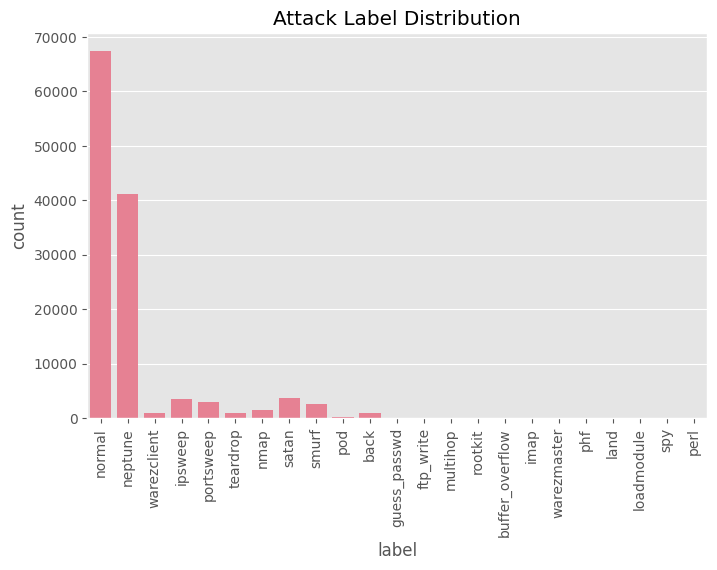

In [125]:
plt.figure(figsize=(8,5))
sns.countplot(x='label', data=df_train)
plt.xticks(rotation=90)
plt.title("Attack Label Distribution")
plt.show()
#Plot Class Distribution

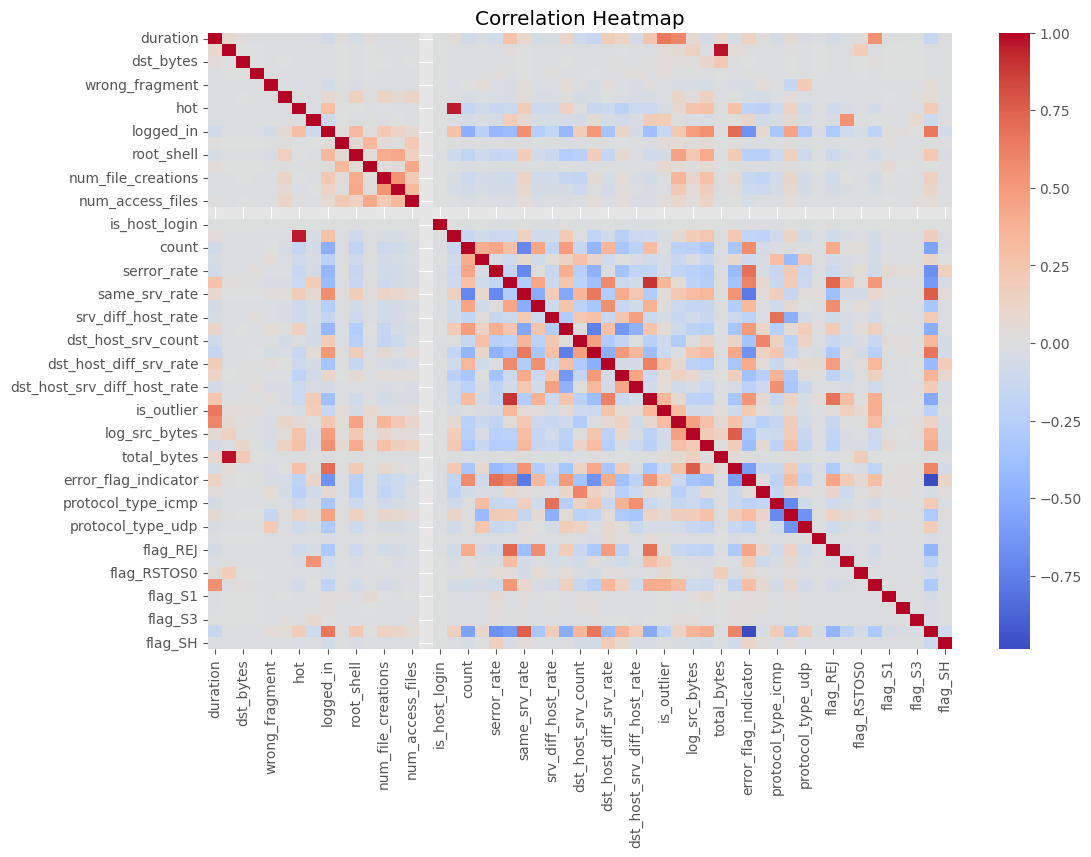

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns from the dataset
numeric_df = df.select_dtypes(include=['number'])
#correlation matrix for numerical features
corr_matrix = numeric_df.corr()
#heatmap visualization
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [116]:
df.select_dtypes(include=['number']).shape

(336715, 53)

In [118]:
import numpy as np
numeric_df = df.select_dtypes(include=['number'])corr_matrix = numeric_df.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("Highly Correlated Features:", to_drop)
df_reduced = df.drop(columns=to_drop)
#here Correlation matrix computation
#Removal of highly correlated features

Highly Correlated Features: ['is_guest_login', 'dst_host_rerror_rate', 'total_bytes']


In [119]:
df.columns

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate',
       'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate', 'is_outlier',
       'log_duration', 'log_src_bytes', 'log_dst_bytes', 'total_bytes',
       'src_bytes_ratio', 'error_flag_indicator', 'service_freq',
       'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp',
       'flag_OTH', 'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH', 'attack_class'],
 

In [120]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Separate features and target
X = df_reduced.drop("attack_class", axis=1)
y = df["attack_class"]   # Use original target

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
# Get feature importance
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

                        Feature  Importance
34              src_bytes_ratio    0.107488
36                 service_freq    0.075438
25           dst_host_srv_count    0.061626
1                     src_bytes    0.060184
32                log_src_bytes    0.057740
8                     logged_in    0.051827
2                     dst_bytes    0.050551
33                log_dst_bytes    0.046402
27       dst_host_diff_srv_rate    0.040845
28  dst_host_same_src_port_rate    0.036777


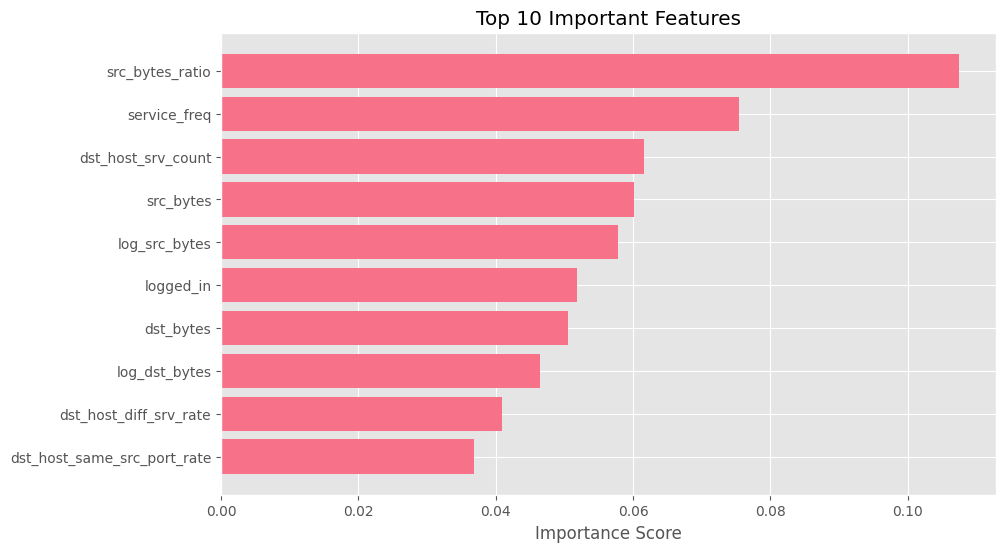

In [121]:
import matplotlib.pyplot as plt
#here Plotting of top 10 important features in horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["Feature"].head(10),
         feature_importance_df["Importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

In [105]:
#Log transformations
df['log_duration'] = np.log1p(df['duration'])
df['log_src_bytes'] = np.log1p(df['src_bytes'])
df['log_dst_bytes'] = np.log1p(df['dst_bytes'])

#Total bytes feature
df['total_bytes'] = df['src_bytes'] + df['dst_bytes']

#Ratio feature
df['src_bytes_ratio'] = df['src_bytes'] / (df['total_bytes'] + 1)

#Error indicator feature
df['error_flag_indicator'] = df['serror_rate'] + df['rerror_rate']

In [133]:
df['src_bytes_ratio'] = df['src_bytes'] / (df['total_bytes'] + 1)
df.head()#here create ratiofeatuers

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack_class
0,0.0,1.619565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
1,0.0,0.369565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
2,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,DoS
3,0.0,0.681159,15.800388,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
4,0.0,0.561594,0.813953,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal


In [134]:
df['total_bytes'] = df['src_bytes'] + df['dst_bytes']
df.head()#Create Total Bytes Feature

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack_class
0,0.0,1.619565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
1,0.0,0.369565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
2,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,DoS
3,0.0,0.681159,15.800388,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
4,0.0,0.561594,0.813953,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal


In [136]:
X = df.drop("attack_class", axis=1)
y = df["attack_class"]
#Separate features and target variable

In [111]:
#here Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(235700, 53)
(101015, 53)


In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [137]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
#Train the model
rf.fit(X_train, y_train)
#Make predictions on test data
y_pred_rf = rf.predict(X_test)
#Evaluate model performance
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.9997129139236747

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     20023
       Probe       1.00      1.00      1.00     20187
         R2L       1.00      1.00      1.00     20501
         U2R       1.00      1.00      1.00     20054
      normal       1.00      1.00      1.00     20250

    accuracy                           1.00    101015
   macro avg       1.00      1.00      1.00    101015
weighted avg       1.00      1.00      1.00    101015



In [21]:
def create_attack_mapping():
    return {
        # Normal
        'normal': 'normal',
        #DoS
        'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS',
        'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
        'mailbomb': 'DoS', 'apache2': 'DoS',
        'processtable': 'DoS', 'udpstorm': 'DoS',
        #Probe
        'satan': 'Probe', 'ipsweep': 'Probe',
        'nmap': 'Probe', 'portsweep': 'Probe',
        'mscan': 'Probe', 'saint': 'Probe',
        #R2L
        'guess_passwd': 'R2L', 'ftp_write': 'R2L',
        'imap': 'R2L', 'phf': 'R2L',
        'multihop': 'R2L', 'warezmaster': 'R2L',
        'warezclient': 'R2L', 'spy': 'R2L',
        'xlock': 'R2L', 'xsnoop': 'R2L',
        'snmpguess': 'R2L', 'snmpgetattack': 'R2L',
        'httptunnel': 'R2L', 'sendmail': 'R2L',
        'named': 'R2L',
        # U2R
        'buffer_overflow': 'U2R', 'loadmodule': 'U2R',
        'perl': 'U2R', 'rootkit': 'U2R',
        'ps': 'U2R', 'xterm': 'U2R',
        'sqlattack': 'U2R'
    }

In [22]:
#mapping applied
attack_map = create_attack_mapping()
df_train['attack_class'] = df_train['label'].map(attack_map)
df_test['attack_class']  = df_test['label'].map(attack_map)

In [23]:
#To Check distribution
print("\nAttack Class Distribution (Train):")
print(df_train['attack_class'].value_counts())


Attack Class Distribution (Train):
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [24]:
#Explicit categorical features
cat_cols = ['protocol_type', 'service', 'flag']
# Binary features
bin_cols = ['land', 'logged_in', 'is_host_login', 'is_guest_login']
#Automatically detect numeric columns
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
#Remove unwanted columns from numeric list
remove_cols = cat_cols + bin_cols + ['label', 'difficulty_level']
num_cols = [col for col in num_cols if col not in remove_cols]

In [25]:
#Print Feature Counts
print("Categorical Features Count :", len(cat_cols))
print("Binary Features Count      :", len(bin_cols))
print("Numerical Features Count   :", len(num_cols))

Categorical Features Count : 3
Binary Features Count      : 4
Numerical Features Count   : 34


In [26]:
#Check Missing Values
print("\nMissing Values in Training Data:")
print(df_train.isnull().sum())


Missing Values in Training Data:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_

In [28]:
def detect_outliers_iforest(data, num_cols, contamination_rate=0.01):
    #numerical data
    numeric_data = data[num_cols]
    #Scale numerical features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_data)
    #here Building Isolation Forest model
    iso_model = IsolationForest(
        contamination=contamination_rate,
        random_state=42
    )
    #Fit and predict
    predictions = iso_model.fit_predict(scaled_data)
    outlier_flags = (predictions == -1).astype(int)  
    total_outliers = outlier_flags.sum()
    print(f"Total Outliers Detected: {total_outliers}")  
    return outlier_flags

In [29]:
#Applying to training data
df_train["is_outlier"] = detect_outliers_iforest(df_train, num_cols)

Total Outliers Detected: 1256


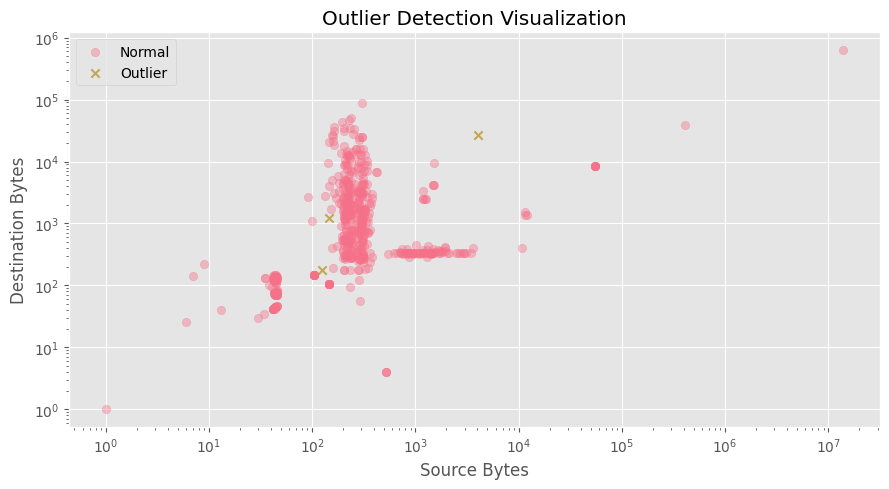

In [33]:
sample_df = df_train.iloc[::100].copy()
plt.figure(figsize=(9,5))
#Separatingthe normal and outliers
normal_points = sample_df[sample_df['is_outlier'] == 0]
outlier_points = sample_df[sample_df['is_outlier'] == 1]
#Ploting normal points
plt.scatter(
    normal_points['src_bytes'],
    normal_points['dst_bytes'],
    alpha=0.4,
    label='Normal'
)
# Plot outliers
plt.scatter(
    outlier_points['src_bytes'],
    outlier_points['dst_bytes'],
    alpha=0.8,
    marker='x',
    label='Outlier'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Source Bytes")
plt.ylabel("Destination Bytes")
plt.title("Outlier Detection Visualization")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
#transformation of log
def log_transform_features(data, feature_list): 
    updated_df = data.copy() 
    for feature in feature_list:   
        transformed_name = "log_" + feature #Creating column
        updated_df[transformed_name] = np.log1p(updated_df[feature])
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))#for visulaization
        #Original Distribution
        sns.histplot(updated_df[feature], bins=30, kde=True, ax=axes[0])
        axes[0].set_title(f"Before Log Transform: {feature}")
        #Transformed Distribution
        sns.histplot(updated_df[transformed_name], bins=30, kde=True, ax=axes[1])
        axes[1].set_title(f"After Log Transform: {transformed_name}")
        plt.tight_layout()
        plt.show() 
    return updated_df

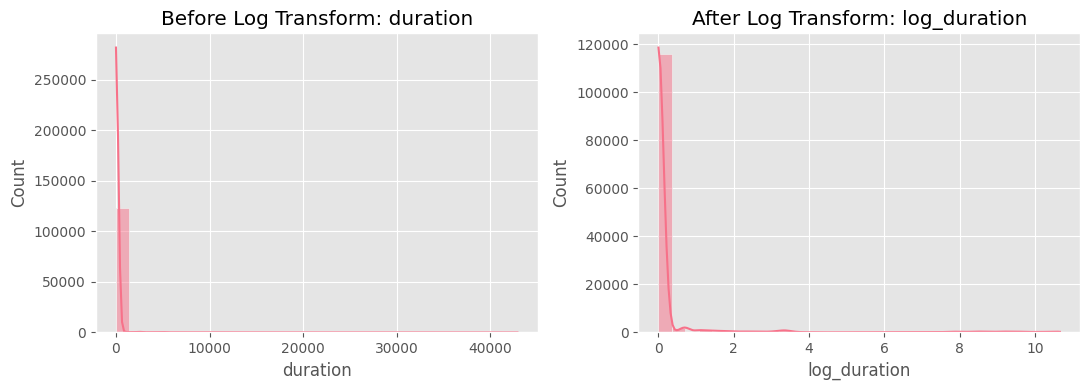

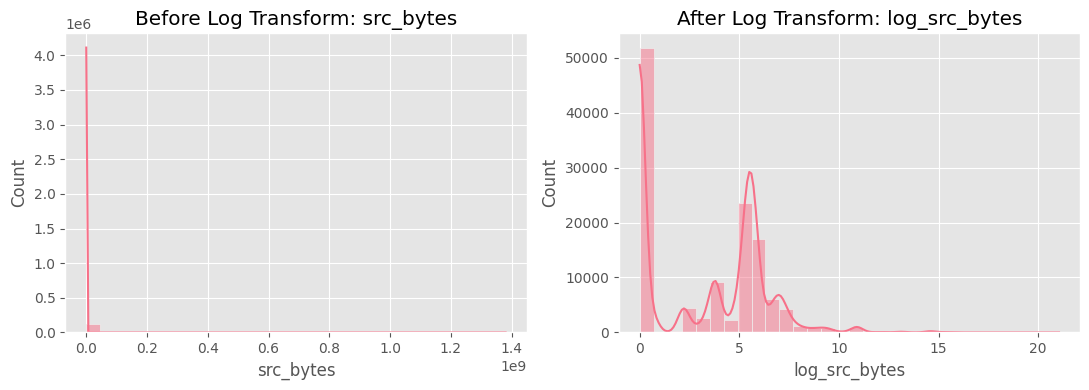

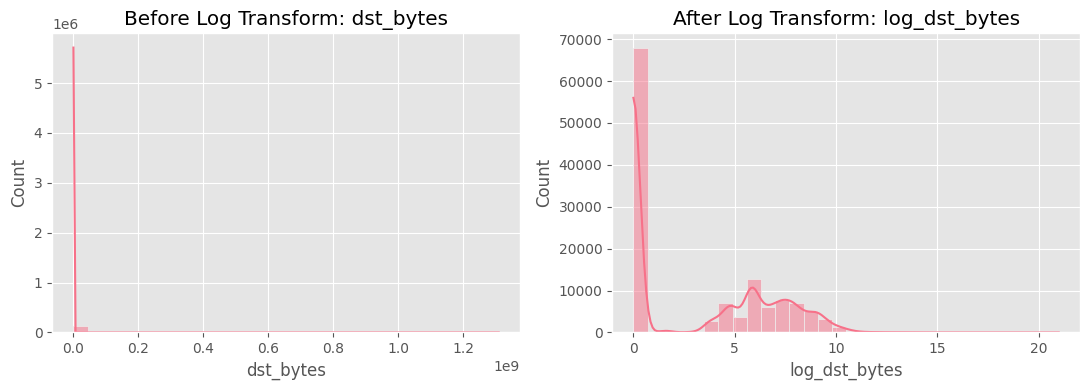

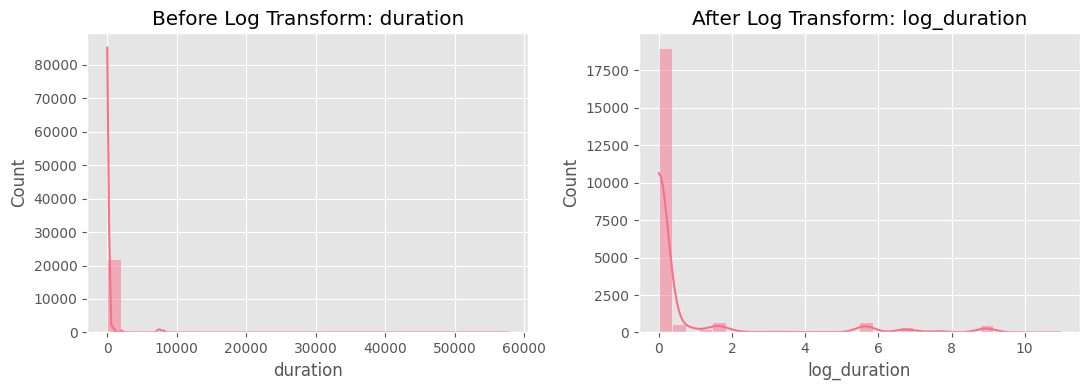

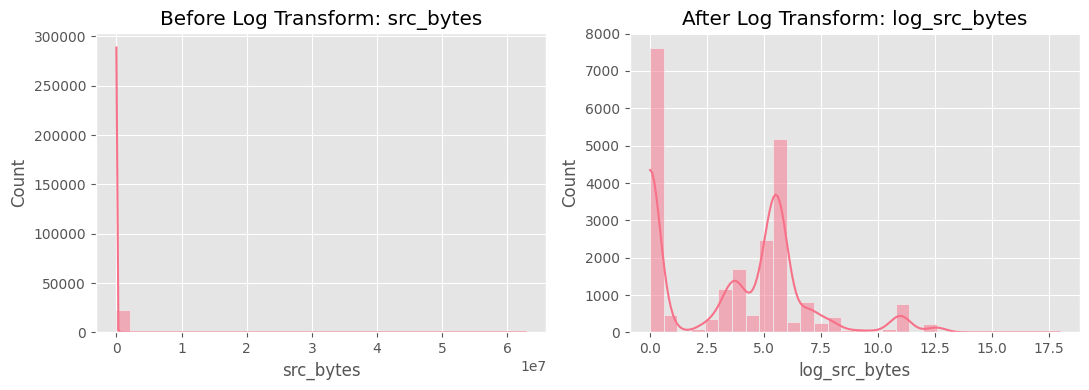

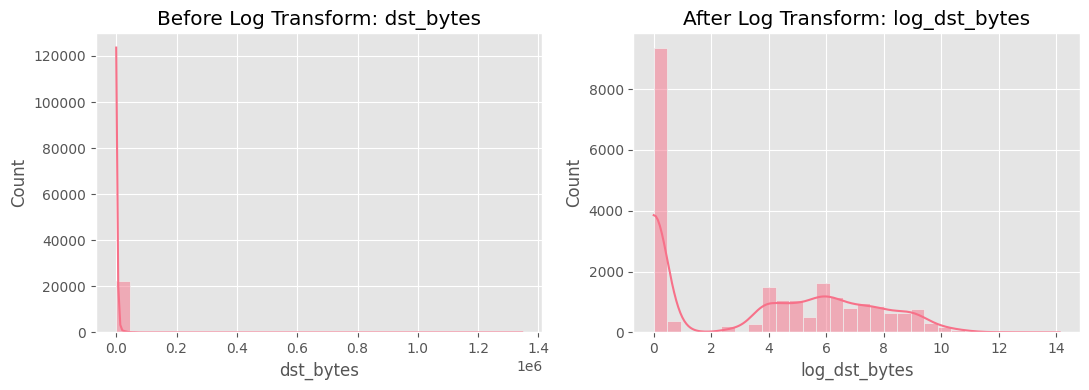

In [35]:
skew_features = ['duration', 'src_bytes', 'dst_bytes']
df_train = log_transform_features(df_train, skew_features)
df_test  = log_transform_features(df_test, skew_features)

In [38]:
def create_additional_features(data):
    df_new = data.copy()
    total_bytes = df_new['src_bytes'] + df_new['dst_bytes']   
    df_new = df_new.assign(
        total_bytes = total_bytes,
        src_bytes_ratio = np.where(
            total_bytes == 0,
            0,
            df_new['src_bytes'] / total_bytes
        ),
        byte_difference = (df_new['src_bytes'] - df_new['dst_bytes']).abs()
    )
    #Traffic Intensity
    df_new['packet_rate'] = np.where(
        df_new['duration'] == 0,
        df_new['count'],
        df_new['count'] / df_new['duration']
    )
    #Flag Based Feature
    error_flag_values = {'S0', 'S1', 'S2', 'S3', 'REJ'}
    df_new['error_flag_indicator'] = df_new['flag'].apply(
        lambda x: 1 if x in error_flag_values else 0
    )
    #Interaction Feature
    df_new['srv_rate_product'] = (
        df_new['same_srv_rate'] * df_new['dst_host_same_srv_rate']
    )  
    return df_new
#Apply Feature Engineering
df_train = create_additional_features(df_train)
df_test  = create_additional_features(df_test)

print("Engineered Feature Preview:\n")
print(df_train[['src_bytes_ratio', 'packet_rate',
                'error_flag_indicator', 'srv_rate_product']].head())

Engineered Feature Preview:

   src_bytes_ratio  packet_rate  error_flag_indicator  srv_rate_product
0         1.000000          2.0                     0             0.170
1         1.000000         13.0                     0             0.000
2         0.000000        123.0                     1             0.005
3         0.027668          5.0                     0             1.000
4         0.321486         30.0                     0             1.000


In [39]:
df_train['service']

0         ftp_data
1            other
2          private
3             http
4             http
            ...   
125968     private
125969     private
125970        smtp
125971      klogin
125972    ftp_data
Name: service, Length: 125973, dtype: str

In [46]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

def encode_categorical_features(train_df, test_df): 
    train_copy = train_df.copy()
    test_copy  = test_df.copy()
    encode_cols = ['protocol_type', 'flag']
    encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )
    encoder.fit(train_copy[encode_cols])

    train_encoded = encoder.transform(train_copy[encode_cols])
    test_encoded  = encoder.transform(test_copy[encode_cols])
    
    encoded_col_names = encoder.get_feature_names_out(encode_cols)
    
    train_encoded_df = pd.DataFrame(train_encoded,
                                    columns=encoded_col_names,
                                    index=train_copy.index)
    test_encoded_df = pd.DataFrame(test_encoded,
                                   columns=encoded_col_names,
                                   index=test_copy.index)
    
    service_distribution = train_copy['service'].value_counts(normalize=True)
    
    train_copy['service_freq'] = train_copy['service'].map(service_distribution)
    test_copy['service_freq']  = test_copy['service'].map(service_distribution).fillna(0)
    
    train_final = train_copy.join(train_encoded_df).drop(columns=encode_cols)
    test_final  = test_copy.join(test_encoded_df).drop(columns=encode_cols)
    
    return train_final, test_final


df_train_encoded, df_test_encoded = encode_categorical_features(df_train, df_test)
print(df_train_encoded.columns)

Index(['duration', 'service', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_root',
       'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label',
       'difficulty_level', 'attack_class', 'is_outlier', 'log_duration',
       'log_src_bytes', 'log_dst_bytes', 'total_bytes', 'src_bytes_ratio',
       'byte_difference', 'packet_rate', 'error_flag_ind

In [48]:
print(df_train_encoded.columns)

Index(['duration', 'service', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_root',
       'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label',
       'difficulty_level', 'attack_class', 'is_outlier', 'log_duration',
       'log_src_bytes', 'log_dst_bytes', 'total_bytes', 'src_bytes_ratio',
       'byte_difference', 'packet_rate', 'error_flag_ind

In [49]:
print(df_test_encoded.columns)

Index(['duration', 'service', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_root',
       'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label',
       'difficulty_level', 'attack_class', 'log_duration', 'log_src_bytes',
       'log_dst_bytes', 'total_bytes', 'src_bytes_ratio', 'byte_difference',
       'packet_rate', 'error_flag_indicator', 'srv_

In [58]:
df_train_encoded.drop(
    columns=['protocol_type','flag','service'],
    inplace=True,
    errors='ignore'
)
df_test_encoded.drop(
    columns=['protocol_type','flag','service'],
    inplace=True,
    errors='ignore'
)

In [53]:
print("Train Shape :", df_train_encoded.shape)
print("Test Shape  :", df_test_encoded.shape)

Train Shape : (125973, 66)
Test Shape  : (22544, 65)


In [55]:
df_train_encoded

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
125969,8,105,145,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125970,0,2231,384,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125971,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [56]:
df_train_encoded

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
125969,8,105,145,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125970,0,2231,384,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125971,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [63]:
import numpy as np
import pandas as pd
#Feature Engineering Pipeline
def build_engineered_features(input_df):
    df = input_df.copy()
    
    #Traffic Volume Features
    df["total_bytes"] = df["src_bytes"] + df["dst_bytes"]
    df["src_byte_ratio"] = np.where(
        df["total_bytes"] == 0,
        0,
        df["src_bytes"] / df["total_bytes"]
    )
    df["byte_asymmetry"] = (df["src_bytes"] - df["dst_bytes"]).abs()

    #Connection Activity Feature
    df["traffic_rate"] = np.where(
        df["duration"] == 0,
        df["count"],
        df["count"] / (df["duration"] + 1e-5)
    )

    #Suspicious Flag Indicator
    suspicious_flags = {"S0", "S1", "S2", "S3", "REJ"}
    df["error_flag"] = df["flag"].apply(
        lambda x: 1 if x in suspicious_flags else 0
    )

    #Interaction Feature
    df["srv_host_interaction"] = (
        df["same_srv_rate"] * df["dst_host_same_srv_rate"]
    )
    return df

In [65]:
# Apply Feature Engineering
df_train = build_engineered_features(df_train)
df_test = build_engineered_features(df_test)

In [68]:
def remove_highly_correlated_features(train_df, test_df, threshold=0.95):
    # Work only with numeric features
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns
    corr_matrix = train_df[numeric_cols].corr().abs()
    # Upper triangle mask
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    upper_triangle = corr_matrix.where(mask)
    drop_features = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]
    print(f"Features removed due to correlation > {threshold}:")
    print(drop_features)
    # Drop features safely
    train_reduced = train_df.drop(columns=drop_features, errors='ignore')
    test_reduced = test_df.drop(columns=drop_features, errors='ignore')
    return train_reduced, test_reduced
# Apply correlation filtering
df_train_reduce, df_test_reduce = remove_highly_correlated_features(
    df_train_encoded,
    df_test_encoded,
    threshold=0.95
)
print("Reduced Training Shape:", df_train_reduce.shape)

Features removed due to correlation > 0.95:
['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'byte_difference', 'packet_rate', 'srv_rate_product', 'flag_S0']
Reduced Training Shape: (125973, 56)


In [69]:
print(df_train_encoded.columns)
print(to_drop)

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'byte_difference', 'packet_rate',
       'error_flag_indicator', 's

In [72]:
from sklearn.preprocessing import RobustScaler

exclude_cols = ['label','attack_class','difficulty_level','is_outlier']
#Select scaling features
scale_cols = df_train_reduce.select_dtypes(include=[np.number]).columns
scale_features = [c for c in scale_cols if c not in exclude_cols]
scaler = RobustScaler()

# Convert columns to float 
df_train_reduce[scale_features] = df_train_reduce[scale_features].astype(float)
df_test_reduce[scale_features] = df_test_reduce[scale_features].astype(float)

# Fitting scaler on training data only
df_train_reduce.loc[:, scale_features] = scaler.fit_transform(
    df_train_reduce[scale_features]
)

# Transform test data
df_test_reduce.loc[:, scale_features] = scaler.transform(
    df_test_reduce[scale_features]
)

print(df_train_reduce[scale_features].describe())

           duration     src_bytes     dst_bytes           land  \
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   
mean      287.14465  1.649375e+02  3.833162e+01       0.000198   
std      2604.51531  2.126932e+04  7.793157e+03       0.014086   
min         0.00000 -1.594203e-01  0.000000e+00       0.000000   
25%         0.00000 -1.594203e-01  0.000000e+00       0.000000   
50%         0.00000  0.000000e+00  0.000000e+00       0.000000   
75%         0.00000  8.405797e-01  1.000000e+00       0.000000   
max     42908.00000  4.999869e+06  2.538638e+06       1.000000   

       wrong_fragment         urgent            hot  num_failed_logins  \
count   125973.000000  125973.000000  125973.000000      125973.000000   
mean         0.022687       0.000111       0.204409           0.001222   
std          0.253530       0.014366       2.149968           0.045239   
min          0.000000       0.000000       0.000000           0.000000   
25%          0.000000       0.00000

In [73]:
df_train_reduce[scale_features[:5]]

,duration,src_bytes,dst_bytes,land,wrong_fragment
0,0.0,1.619565,0.000000,0.0,0.0
1,0.0,0.369565,0.000000,0.0,0.0
2,0.0,-0.159420,0.000000,0.0,0.0
3,0.0,0.681159,15.800388,0.0,0.0
4,0.0,0.561594,0.813953,0.0,0.0
...,...,...,...,...,...
125968,0.0,-0.159420,0.000000,0.0,0.0
125969,8.0,0.221014,0.281008,0.0,0.0
125970,0.0,7.923913,0.744186,0.0,0.0
125971,0.0,-0.159420,0.000000,0.0,0.0


In [74]:
from imblearn.over_sampling import SMOTE

#Select target column
target_variable = 'attack_class'

#Separate features and target
feature_data = df_train_reduce.drop(
    columns=['label', 'attack_class', 'difficulty_level'],
    errors='ignore'
)

target_data = df_train_reduce[target_variable]

#Show distribution before balancing
print("Class Distribution Before Balancing")
print(target_data.value_counts())

#Replace missing values
feature_data = feature_data.fillna(0)

#Initialize SMOTE model
smote_model = SMOTE(
    k_neighbors=5,
    random_state=42
)

#Perform oversampling
X_balanced, y_balanced = smote_model.fit_resample(
    feature_data,
    target_data
)
print("\nClass Distribution After Balancing")
print(y_balanced.value_counts())

# View balanced target samples
y_balanced.head()

Class Distribution Before Balancing
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Class Distribution After Balancing
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


0    normal
1    normal
2       DoS
3    normal
4    normal
Name: attack_class, dtype: str

In [77]:
from imblearn.over_sampling import SMOTE
target_col = 'attack_class'
#Features and target separation
X = df_train_reduce.drop(
    columns=['label','attack_class','difficulty_level'],
    errors='ignore'
)
y = df_train_reduce[target_col]
print("Before SMOTE:")
print(y.value_counts())
#Handle missing values
X = X.fillna(0)
#SMOTE balancing
smote = SMOTE(k_neighbors=5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

After SMOTE:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


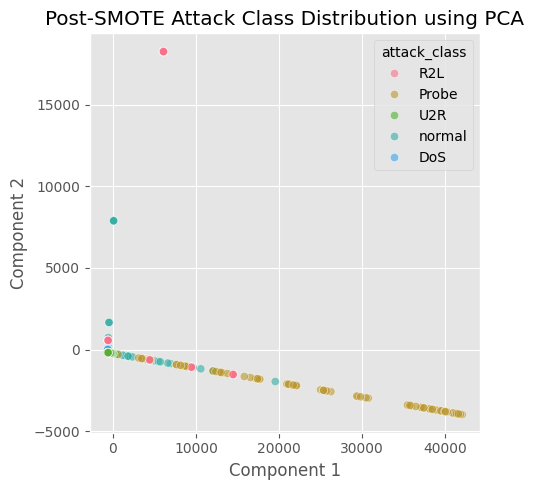

In [78]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
#Reduce dataset size for visualization
sample_size = 5000
X_vis = X_resampled.sample(sample_size, random_state=42)
y_vis = y_resampled.sample(sample_size, random_state=42)

#PCA transformation appling here
pca_model = PCA(n_components=2)
pca_features = pca_model.fit_transform(X_vis)

# Plot PCA scatter visualization
plt.figure(figsize=(5,5))
sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=y_vis,
    alpha=0.6
)

plt.title("Post-SMOTE Attack Class Distribution using PCA")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

In [80]:
import os
import pandas as pd

df_final_train = pd.concat([X_resampled, y_resampled], axis=1)

output_dir = "../SentinelNet/data/processed/"

os.makedirs(output_dir, exist_ok=True)

save_file_path = os.path.join(output_dir, "train_processed_advanced.csv")

df_final_train.to_csv(save_file_path, index=False)

print("Saved Processed Data:", save_file_path)

Saved Processed Data: ../SentinelNet/data/processed/train_processed_advanced.csv
